In [1]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
from datetime import datetime

In [2]:
# force 'normal' text style for math text
mpl.rcParams['mathtext.default'] = 'regular'

# set global seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [3]:
ts = pd.read_csv('MOD-00691.csv')
COLS_TO_INCLUDE = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','pm25','co','o3','no','no2','rh','temp']
ts = ts[COLS_TO_INCLUDE]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-31T18:59:34Z,6.169,0.652,0.217,0.057,0.027,0.004,5.863,1158.375,24.425,2.424,37.685,51.5,0.0
1,2025-12-31T18:58:34Z,6.513,0.912,0.194,0.036,0.022,0.018,6.280,1285.293,24.792,2.293,36.979,51.4,0.0
2,2025-12-31T18:57:34Z,6.793,0.800,0.232,0.062,0.022,0.018,7.014,1714.006,25.170,2.812,36.276,51.2,0.0
3,2025-12-31T18:56:34Z,6.516,0.755,0.209,0.047,0.047,0.017,6.707,2682.790,24.746,2.424,37.199,51.8,0.0
4,2025-12-31T18:55:34Z,6.421,0.860,0.280,0.026,0.036,0.026,6.808,1489.066,25.476,2.424,36.963,51.6,-0.1


In [4]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local'],format="%Y-%m-%dT%H:%M:%SZ") #convert timestamp column to pandas timestamp format
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-31 18:59:34,6.169,0.652,0.217,0.057,0.027,0.004,5.863,1158.375,24.425,2.424,37.685,51.5,0.0
1,2025-12-31 18:58:34,6.513,0.912,0.194,0.036,0.022,0.018,6.280,1285.293,24.792,2.293,36.979,51.4,0.0
2,2025-12-31 18:57:34,6.793,0.800,0.232,0.062,0.022,0.018,7.014,1714.006,25.170,2.812,36.276,51.2,0.0
3,2025-12-31 18:56:34,6.516,0.755,0.209,0.047,0.047,0.017,6.707,2682.790,24.746,2.424,37.199,51.8,0.0
4,2025-12-31 18:55:34,6.421,0.860,0.280,0.026,0.036,0.026,6.808,1489.066,25.476,2.424,36.963,51.6,-0.1


## Full Timeseries Plot

In [5]:
#taking daily average of ts. round to floor of the day
ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-03-31,22.450279,4.460900,1.477600,0.442229,0.568213,0.456433,9.322729,1096.936025,32.255204,2.566058,33.167983,87.528750,16.238750
2025-04-01,4.769358,1.021788,0.325635,0.069387,0.062042,0.031803,3.086333,847.044780,43.241578,2.198538,24.225906,45.111111,12.990069
2025-04-02,3.138873,0.610540,0.349769,0.130714,0.180913,0.151186,4.378065,781.747863,49.049917,2.033232,30.100430,42.502361,8.289375
2025-04-03,18.414944,2.881694,1.009292,0.363367,0.537003,0.461712,12.076046,1008.601460,29.493521,2.292700,28.032072,78.442708,15.762847
2025-04-04,4.490936,0.550246,0.210607,0.061139,0.078733,0.056989,4.626377,923.985363,38.173867,2.176622,20.548473,45.781215,20.958380


In [6]:
ts_day['pm25_c'] = 3.491 + 0.576*ts_day['pm25'] - 0.047*ts_day['rh'] + 0.070*ts_day['temp']
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-03-31,22.450279,4.460900,1.477600,0.442229,0.568213,0.456433,9.322729,1096.936025,32.255204,2.566058,33.167983,87.528750,16.238750,5.883753
2025-04-01,4.769358,1.021788,0.325635,0.069387,0.062042,0.031803,3.086333,847.044780,43.241578,2.198538,24.225906,45.111111,12.990069,4.057810
2025-04-02,3.138873,0.610540,0.349769,0.130714,0.180913,0.151186,4.378065,781.747863,49.049917,2.033232,30.100430,42.502361,8.289375,4.595410
2025-04-03,18.414944,2.881694,1.009292,0.363367,0.537003,0.461712,12.076046,1008.601460,29.493521,2.292700,28.032072,78.442708,15.762847,7.863394
2025-04-04,4.490936,0.550246,0.210607,0.061139,0.078733,0.056989,4.626377,923.985363,38.173867,2.176622,20.548473,45.781215,20.958380,5.471163


<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_12074/514874767.py:45: SyntaxWarning: invalid escape sequence '\m'
  ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)


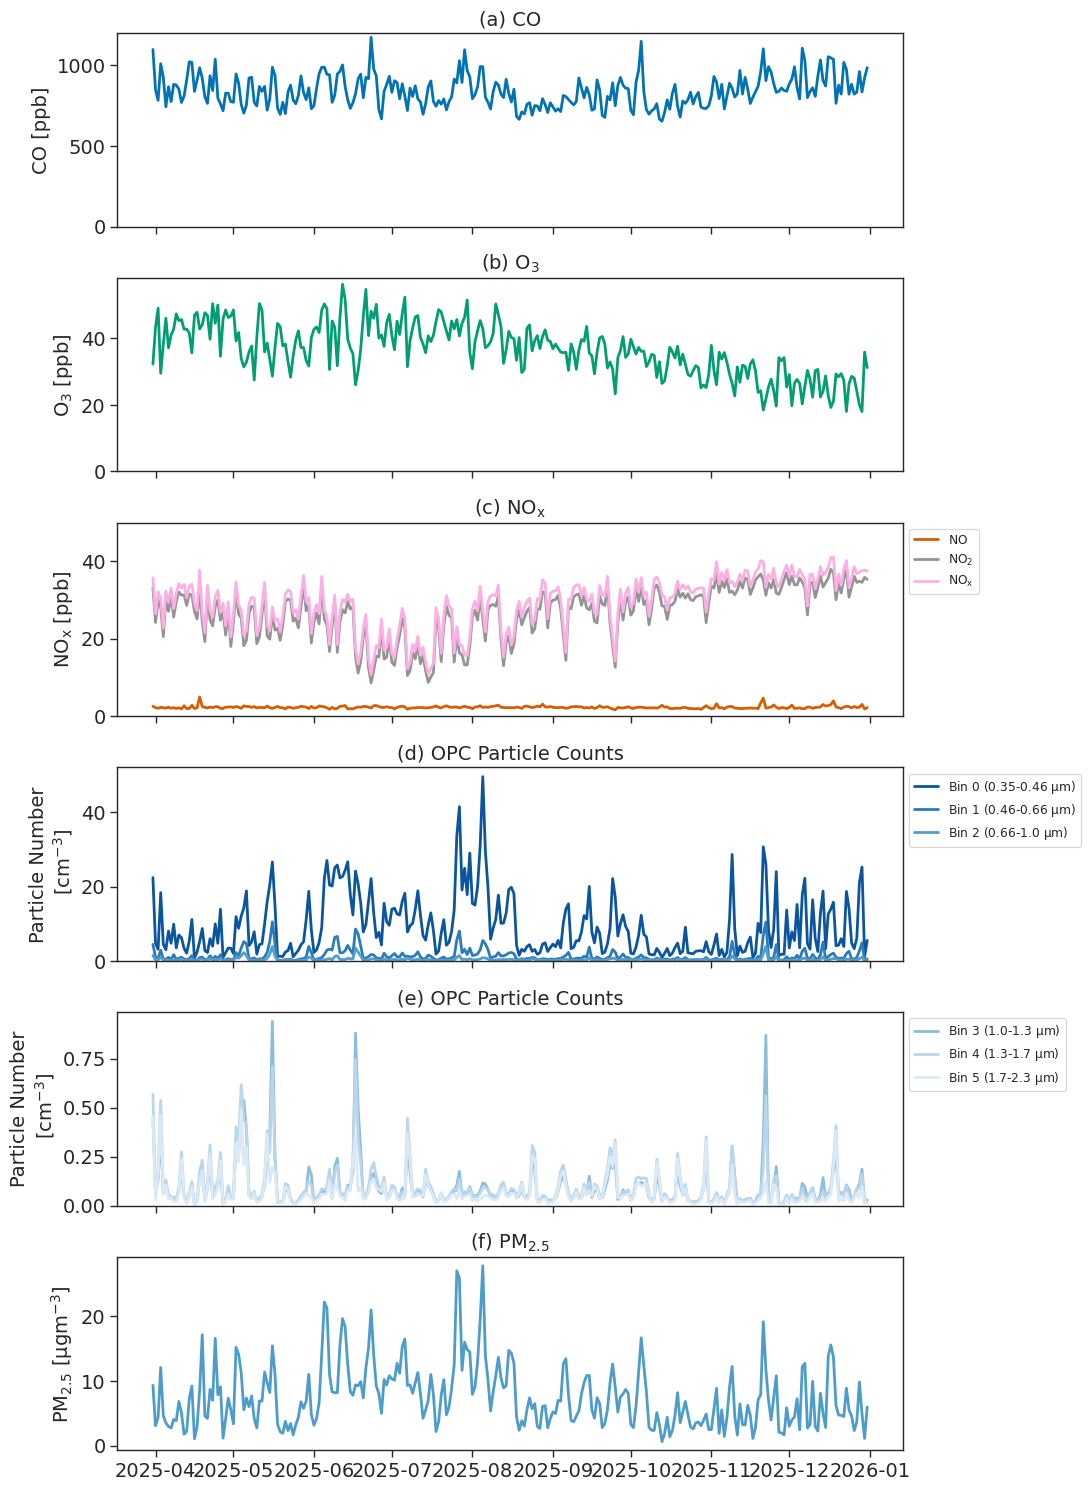

In [7]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(ts_day['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(0, None)

# plot the o3 on the second axis
ax[1].plot(ts_day['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(0, None)

#plot nox on the 2nd axis
ax[2].plot(ts_day['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(ts_day['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(ts_day['no2']+ts_day['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 50)


# plot the OPC bins on the 5th and 6th rows
ax[3].plot(ts_day['bin0'], lw=2, label=r'Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(ts_day['bin1'], lw=2, label=r'Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(ts_day['bin2'], lw=2, label=r'Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(ts_day['bin3'], lw=2, label=r'Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(ts_day['bin4'], lw=2, label=r'Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(ts_day['bin5'], lw=2, label=r'Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(ts_day['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(d) OPC Particle Counts", fontsize=14)
ax[4].set_title("(e) OPC Particle Counts", fontsize=14)
ax[5].set_title("(f) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

# force a tight layout
plt.tight_layout()

# fig.savefig('C:/Users/alexa/Jupyter Notebook/MOD-00683/timeseries_MOD-00068.png')

## Dirunal Plots

In [8]:
#taking daily average of ts. round to floor of the day
ts_hour = ts.groupby(ts['timestamp_local'].dt.floor('h')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_hour = ts_hour.set_index('timestamp_local')
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-03-31 20:00:00,20.588150,2.422267,1.145667,0.452517,0.632200,0.533567,10.988167,960.720683,28.144733,2.025083,36.114200,82.411667,16.036667
2025-03-31 21:00:00,28.437733,4.943900,1.701750,0.542517,0.736467,0.627367,11.576200,1042.707967,26.455517,2.659317,39.513500,88.971667,15.930000
2025-03-31 22:00:00,24.142150,5.446500,1.655567,0.458417,0.580967,0.461550,8.924467,1250.146617,31.827767,2.792933,35.640617,90.131667,16.498333
2025-03-31 23:00:00,16.633083,5.030933,1.407417,0.315467,0.323217,0.203250,5.802083,1134.168833,42.592800,2.786900,21.403617,88.600000,16.490000
2025-04-01 00:00:00,16.342450,3.755700,1.071383,0.243133,0.252967,0.148850,5.780017,1275.500833,45.239117,2.729217,25.504183,87.136667,16.200000


In [9]:
ts_hour['pm25_c'] = 2.111 + 0.298*ts_hour['pm25'] + 0.024*ts_hour['rh'] + 0.050*ts_hour['temp']
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-03-31 20:00:00,20.588150,2.422267,1.145667,0.452517,0.632200,0.533567,10.988167,960.720683,28.144733,2.025083,36.114200,82.411667,16.036667,8.165187
2025-03-31 21:00:00,28.437733,4.943900,1.701750,0.542517,0.736467,0.627367,11.576200,1042.707967,26.455517,2.659317,39.513500,88.971667,15.930000,8.492528
2025-03-31 22:00:00,24.142150,5.446500,1.655567,0.458417,0.580967,0.461550,8.924467,1250.146617,31.827767,2.792933,35.640617,90.131667,16.498333,7.758568
2025-03-31 23:00:00,16.633083,5.030933,1.407417,0.315467,0.323217,0.203250,5.802083,1134.168833,42.592800,2.786900,21.403617,88.600000,16.490000,6.790921
2025-04-01 00:00:00,16.342450,3.755700,1.071383,0.243133,0.252967,0.148850,5.780017,1275.500833,45.239117,2.729217,25.504183,87.136667,16.200000,6.734725


In [10]:
#prepping data
ts_hour['Hour'] = ts_hour.index.hour
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour
timestamp_local,,,,,,,,,,,,,,,
2025-03-31 20:00:00,20.588150,2.422267,1.145667,0.452517,0.632200,0.533567,10.988167,960.720683,28.144733,2.025083,36.114200,82.411667,16.036667,8.165187,20
2025-03-31 21:00:00,28.437733,4.943900,1.701750,0.542517,0.736467,0.627367,11.576200,1042.707967,26.455517,2.659317,39.513500,88.971667,15.930000,8.492528,21
2025-03-31 22:00:00,24.142150,5.446500,1.655567,0.458417,0.580967,0.461550,8.924467,1250.146617,31.827767,2.792933,35.640617,90.131667,16.498333,7.758568,22
2025-03-31 23:00:00,16.633083,5.030933,1.407417,0.315467,0.323217,0.203250,5.802083,1134.168833,42.592800,2.786900,21.403617,88.600000,16.490000,6.790921,23
2025-04-01 00:00:00,16.342450,3.755700,1.071383,0.243133,0.252967,0.148850,5.780017,1275.500833,45.239117,2.729217,25.504183,87.136667,16.200000,6.734725,0


In [11]:
#groupping by hour and calculate the mean
diurnal_data = ts_hour.groupby('Hour').mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
Hour,,,,,,,,,,,,,,
00:00,9.816133,1.772001,0.541558,0.126664,0.127622,0.084116,7.237002,827.278850,34.404788,2.209629,29.185429,63.903211,16.487335,6.625670
01:00,9.921250,1.678014,0.480100,0.108981,0.113739,0.080647,6.988106,825.251063,33.385748,2.169453,29.066409,65.481328,16.092751,6.569645
02:00,10.070983,1.627963,0.460302,0.107497,0.114365,0.082115,6.767400,818.801399,32.431579,2.095549,28.897468,66.995554,15.743942,6.522776
03:00,10.189524,1.628969,0.448783,0.105742,0.114219,0.082994,6.624800,792.083707,31.545112,2.081909,28.534396,68.155030,15.388455,6.490334
04:00,10.535941,1.760788,0.493118,0.117044,0.122036,0.083684,6.542888,788.108346,30.437294,2.064376,28.726653,69.419508,15.074551,6.480576
05:00,10.750878,1.810078,0.516949,0.123751,0.129312,0.086475,6.569831,841.741213,28.728673,2.068375,29.625638,70.288340,14.886258,6.500043
06:00,10.716868,1.768547,0.511557,0.123872,0.129419,0.088480,6.732476,899.116094,27.323212,2.161183,30.074413,70.258717,14.840242,6.545499
07:00,10.383348,1.601851,0.459636,0.114177,0.125696,0.090650,7.196586,889.257130,26.857837,2.389219,28.354918,65.884097,16.009122,6.637257
08:00,9.918298,1.479335,0.422162,0.101770,0.114363,0.083197,7.676936,881.999628,27.954763,2.734862,25.047996,59.012281,18.184799,6.724262


<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_12074/2783464749.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipykernel_12074/2783464749.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blu

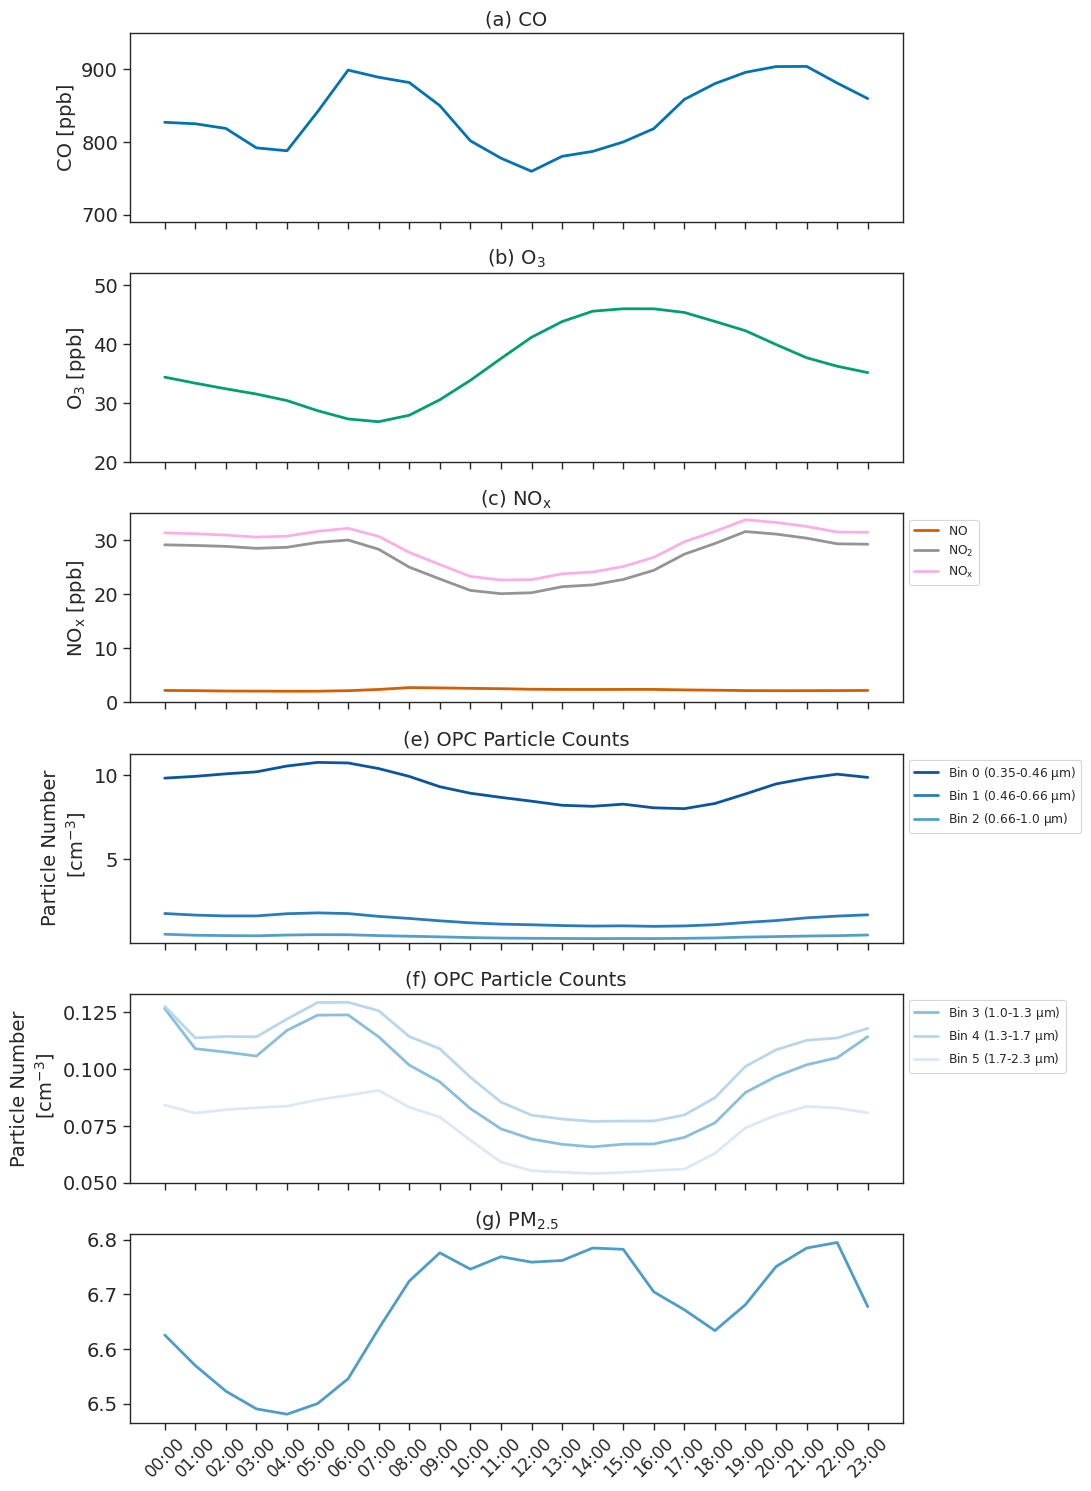

In [12]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(diurnal_data['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(690, 950)

# plot the o3 on the first axis
ax[1].plot(diurnal_data['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(20, 52)

#plot nox on the 2nd axis
ax[2].plot(diurnal_data['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(diurnal_data['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(diurnal_data['no2']+diurnal_data['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 35)

# plot the OPC bins on the 3rd and 4th rows
ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(diurnal_data['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0.05, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(diurnal_data['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(diurnal_data['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(diurnal_data['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0.05, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(diurnal_data['pm25_c'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(e) OPC Particle Counts", fontsize=14)
ax[4].set_title("(f) OPC Particle Counts", fontsize=14)
ax[5].set_title("(g) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# set x as hours
ax[5].set_xticks(range(24))
ax[5].set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

plt.xticks(range(0, 24), size = 12)
plt.xticks(rotation=45)

# force a tight layout
plt.tight_layout()

# fig.savefig('C:/Users/alexa/Jupyter Notebook/MOD-00683/dirunal_MOD-00068_allfeatures.png')

## Diurnal by Season

In [13]:
def month_to_season(month):
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Autumn'
    else:
        return 'Winter'

In [14]:
ts_hour = ts_hour.reset_index()

In [15]:
#prepping data
ts_hour['Season'] = ts_hour['timestamp_local'].dt.month.apply(month_to_season)
ts_hour.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour,Season
0,2025-03-31 20:00:00,20.588150,2.422267,1.145667,0.452517,0.632200,0.533567,10.988167,960.720683,28.144733,2.025083,36.114200,82.411667,16.036667,8.165187,20,Spring
1,2025-03-31 21:00:00,28.437733,4.943900,1.701750,0.542517,0.736467,0.627367,11.576200,1042.707967,26.455517,2.659317,39.513500,88.971667,15.930000,8.492528,21,Spring
2,2025-03-31 22:00:00,24.142150,5.446500,1.655567,0.458417,0.580967,0.461550,8.924467,1250.146617,31.827767,2.792933,35.640617,90.131667,16.498333,7.758568,22,Spring
3,2025-03-31 23:00:00,16.633083,5.030933,1.407417,0.315467,0.323217,0.203250,5.802083,1134.168833,42.592800,2.786900,21.403617,88.600000,16.490000,6.790921,23,Spring
4,2025-04-01 00:00:00,16.342450,3.755700,1.071383,0.243133,0.252967,0.148850,5.780017,1275.500833,45.239117,2.729217,25.504183,87.136667,16.200000,6.734725,0,Spring


In [16]:
grouped_by_season_hour = ts_hour.drop(columns='timestamp_local').groupby(['Season', 'Hour']).mean()
grouped_by_season_hour

bin0      bin1      bin2      bin3      bin4      bin5  \
Season Hour                                                                
Autumn 0      6.162363  1.143591  0.410417  0.105438  0.109510  0.074606   
       1      6.493510  1.007020  0.325632  0.081271  0.091382  0.071102   
       2      6.859162  1.008460  0.322182  0.082937  0.095381  0.076555   
       3      7.215665  1.062746  0.329860  0.084348  0.097397  0.078008   
       4      7.755768  1.208143  0.361885  0.088614  0.095904  0.071229   
...                ...       ...       ...       ...       ...       ...   
Winter 19    10.126791  1.384479  0.373625  0.074097  0.068928  0.044761   
       20    10.453726  1.433703  0.379446  0.076271  0.070113  0.046112   
       21    10.403832  1.530439  0.413737  0.084323  0.077456  0.050966   
       22    11.327880  1.826980  0.460741  0.095228  0.090924  0.056634   
       23    12.090293  2.109098  0.501668  0.095017  0.091766  0.059070   

                 pm25          co         o3        no        no2         rh  \
Season Hour                                                                    
Autumn 0     5.604260  785.506247  31.113952  2.324504  31.705091  62.863446   
       1     5.519193  791.104652  29.875832  2.211788  32.274082  64.945014   
       2     5.429434  785.810791  29.158174  2.055649  32.130714  66.841420   
       3     5.403812  765.563892  28.361791  2.075445  31.977434  68.303028   
       4     5.236549  750.234938  27.371802  2.057723  31.837936  69.563580   
...               ...         ...        ...       ...        ...        ...   
Winter 19    6.289851  943.398778  25.026984  2.171760  36.360805  57.275920   
       20    6.489884  913.478370  24.574984  2.219171  35.951177  58.018621   
       21    6.368945  958.761854  24.751803  2.212583  35.748049  58.531494   
       22    6.451088  858.586600  24.844442  2.260615  35.459174  60.106839   
       23    6.352849  802.554745  24.265053  2.380240  35.560445  61.797414   

                  temp    pm25_c  
Season Hour                       
Autumn 0     15.050599  6.042322  
       1     14.596872  6.044243  
       2     14.285833  6.047457  
       3     13.943764  6.057797  
       4     13.643314  6.023183  
...                ...       ...  
Winter 19     2.217299  5.470862  
       20     1.961724  5.535519  
       21     1.787644  5.503084  
       22     1.648506  5.558414  
       23     1.404713  5.557523  

[96 rows x 14 columns]

In [17]:
grouped_by_season_hour = grouped_by_season_hour.reset_index()
grouped_by_season_hour

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
0,Autumn,0,6.162363,1.143591,0.410417,0.105438,0.109510,0.074606,5.604260,785.506247,31.113952,2.324504,31.705091,62.863446,15.050599,6.042322
1,Autumn,1,6.493510,1.007020,0.325632,0.081271,0.091382,0.071102,5.519193,791.104652,29.875832,2.211788,32.274082,64.945014,14.596872,6.044243
2,Autumn,2,6.859162,1.008460,0.322182,0.082937,0.095381,0.076555,5.429434,785.810791,29.158174,2.055649,32.130714,66.841420,14.285833,6.047457
3,Autumn,3,7.215665,1.062746,0.329860,0.084348,0.097397,0.078008,5.403812,765.563892,28.361791,2.075445,31.977434,68.303028,13.943764,6.057797
4,Autumn,4,7.755768,1.208143,0.361885,0.088614,0.095904,0.071229,5.236549,750.234938,27.371802,2.057723,31.837936,69.563580,13.643314,6.023183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,Winter,19,10.126791,1.384479,0.373625,0.074097,0.068928,0.044761,6.289851,943.398778,25.026984,2.171760,36.360805,57.275920,2.217299,5.470862
92,Winter,20,10.453726,1.433703,0.379446,0.076271,0.070113,0.046112,6.489884,913.478370,24.574984,2.219171,35.951177,58.018621,1.961724,5.535519
93,Winter,21,10.403832,1.530439,0.413737,0.084323,0.077456,0.050966,6.368945,958.761854,24.751803,2.212583,35.748049,58.531494,1.787644,5.503084
94,Winter,22,11.327880,1.826980,0.460741,0.095228,0.090924,0.056634,6.451088,858.586600,24.844442,2.260615,35.459174,60.106839,1.648506,5.558414


In [18]:
autumn_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Autumn']
winter_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Winter']
spring_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Spring']
summer_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Summer']

autumn_diurnal.index = autumn_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
winter_diurnal.index = winter_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
spring_diurnal.index = spring_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
summer_diurnal.index = summer_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))

In [19]:
autumn_diurnal

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
00:00,Autumn,0,6.162363,1.143591,0.410417,0.105438,0.109510,0.074606,5.604260,785.506247,31.113952,2.324504,31.705091,62.863446,15.050599,6.042322
01:00,Autumn,1,6.493510,1.007020,0.325632,0.081271,0.091382,0.071102,5.519193,791.104652,29.875832,2.211788,32.274082,64.945014,14.596872,6.044243
02:00,Autumn,2,6.859162,1.008460,0.322182,0.082937,0.095381,0.076555,5.429434,785.810791,29.158174,2.055649,32.130714,66.841420,14.285833,6.047457
03:00,Autumn,3,7.215665,1.062746,0.329860,0.084348,0.097397,0.078008,5.403812,765.563892,28.361791,2.075445,31.977434,68.303028,13.943764,6.057797
04:00,Autumn,4,7.755768,1.208143,0.361885,0.088614,0.095904,0.071229,5.236549,750.234938,27.371802,2.057723,31.837936,69.563580,13.643314,6.023183
05:00,Autumn,5,8.304595,1.364991,0.407087,0.096049,0.098848,0.070631,5.276420,827.250048,25.705240,2.045379,32.712182,70.846913,13.455625,6.056480
06:00,Autumn,6,8.600478,1.499035,0.463515,0.108009,0.106189,0.071099,5.425238,900.161435,23.956536,2.161972,33.403707,71.612645,13.172538,6.105051
07:00,Autumn,7,8.532583,1.314406,0.402051,0.097417,0.101834,0.071966,5.778759,873.664574,23.637807,2.217503,33.405138,69.662051,13.660400,6.187979
08:00,Autumn,8,7.698506,1.089038,0.342289,0.087477,0.098501,0.070964,6.354475,891.798068,24.812165,2.341619,29.162346,61.854817,15.967711,6.287535
09:00,Autumn,9,6.567590,0.944211,0.313482,0.082125,0.095562,0.068714,6.435961,818.189880,27.192048,2.597430,26.147803,53.601648,18.606447,6.245678


In [20]:
seasons_order = [winter_diurnal, spring_diurnal, summer_diurnal, autumn_diurnal]

<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_12074/1559231832.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipykernel_12074/1559231832.py:41: SyntaxWarning: invalid escape sequence '

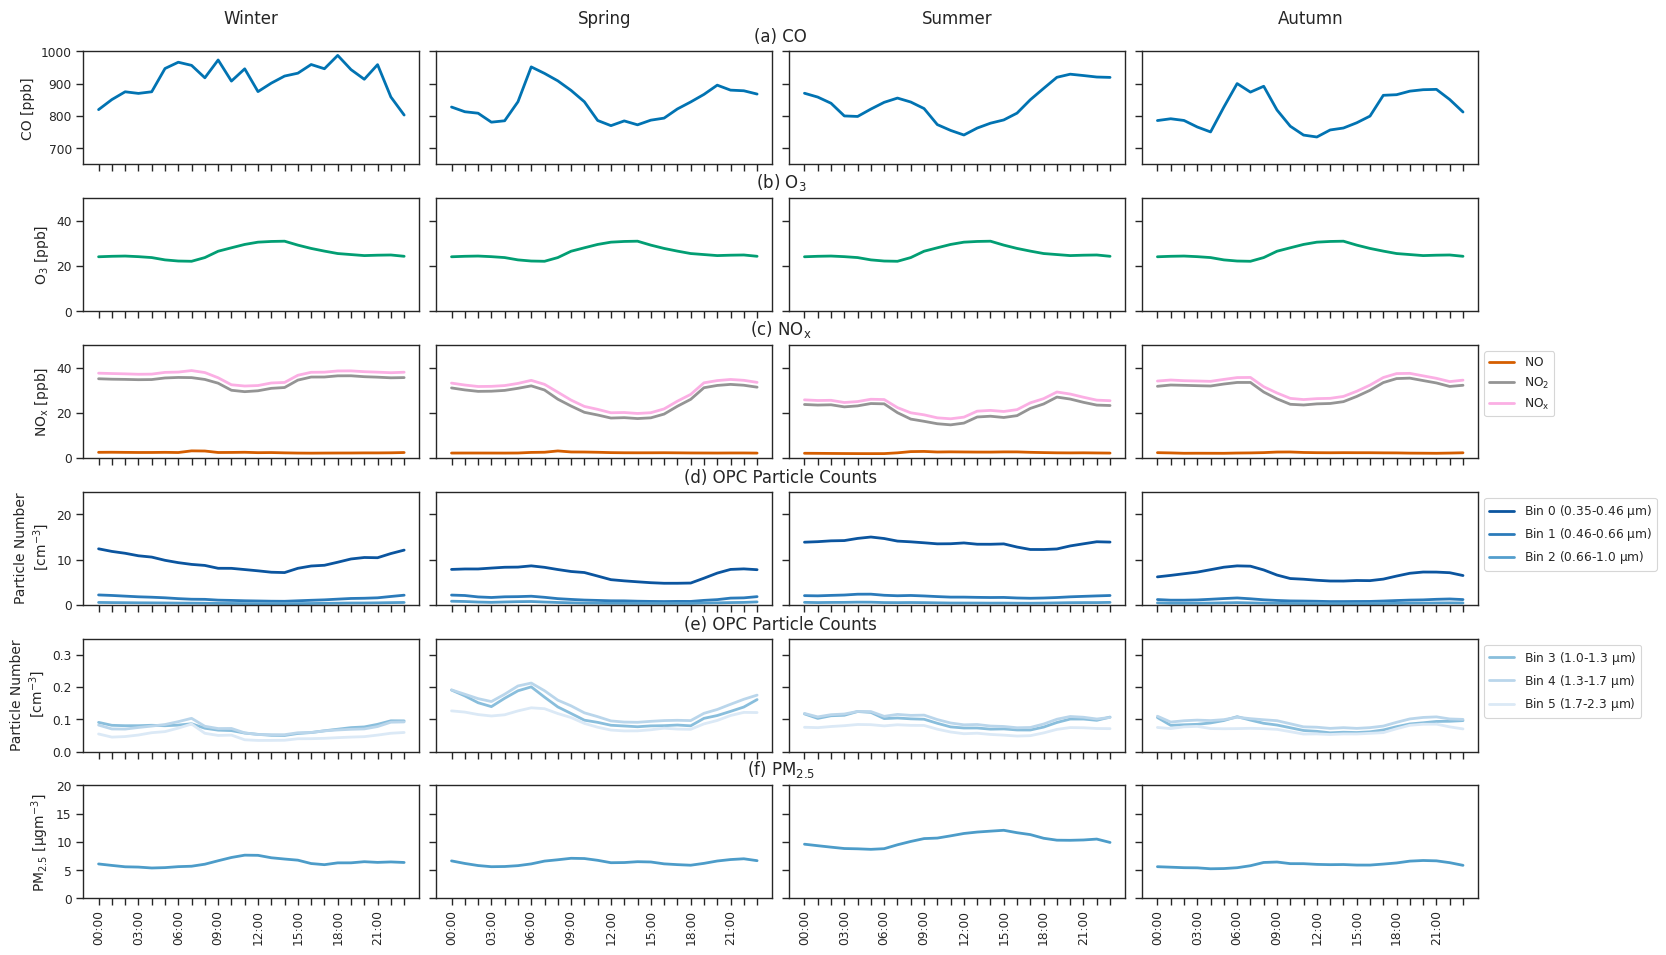

In [21]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=4, figsize=(18,11), sharex=True)
plt.subplots_adjust(hspace = 0.3, wspace = 0.05)

# grab the current color palette
cmap = sns.color_palette()

#iterate through seasons
for i in range(len(seasons_order)):

    #set ax column labels as season
    ax[0,0].set_title("Winter", fontsize=12, pad = 20)
    ax[0,1].set_title("Spring", fontsize=12, pad = 20)
    ax[0,2].set_title("Summer", fontsize=12, pad = 20)
    ax[0,3].set_title("Autumn", fontsize=12, pad = 20)

    # plot the CO data and label the axis
    ax[0,0].set_ylabel("CO [ppb]", fontsize=10)
    ax[0,i].plot(seasons_order[i]['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
    ax[0,i].set_ylim(650, 1000)
    ax[0,i].set_xticks(range(0, 2))
    ax[0,i].set_xticks(seasons_order[i].index)

    # plot the o3 on the second axis
    ax[1,0].set_ylabel("$O_3$ [ppb]", fontsize=10)
    ax[1,i].plot(winter_diurnal['o3'], lw=2, label="$O_3$", color=cmap[2])
    ax[1,i].set_ylim(0, 50)

    #plot nox on the 3rd axis
    ax[2,0].set_ylabel("$NO_x$ [ppb]", fontsize=10)
    ax[2,i].plot(seasons_order[i]['no'], lw=2, label="$NO$", color=cmap[3])
    ax[2,i].plot(seasons_order[i]['no2'], lw=2, label="$NO_2$", color=cmap[7])
    ax[2,i].plot(seasons_order[i]['no2']+seasons_order[i]['no'], lw=2, label="$NO_x$", color=cmap[6])
    ax[2,i].set_ylim(0, 50)
    ax[2,3].legend(fontsize = 14)
    sns.move_legend(ax[2,3], "upper left", bbox_to_anchor=(1, 1))

    # plot the OPC bins on the 4th and 5th rows
    ax[3,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
    ax[3,i].plot(seasons_order[i]['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
    ax[3,i].plot(seasons_order[i]['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
    ax[3,i].set(ylim=(0, 25))
    ax[3,3].legend(fontsize = 14)
    sns.move_legend(ax[3,3], "upper left", bbox_to_anchor=(1, 1))

    ax[4,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[4,i].plot(seasons_order[i]['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
    ax[4,i].plot(seasons_order[i]['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
    ax[4,i].plot(seasons_order[i]['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
    ax[4,i].set(ylim=(0, 0.35))
    ax[4,3].legend(fontsize = 14)
    sns.move_legend(ax[4,3], "upper left", bbox_to_anchor=(1, 1))

    #plot pm25 on the 6th row
    ax[5,0].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=10)
    ax[5,i].plot(seasons_order[i]['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
    ax[5,i].set(ylim=(0, 20))
    ax[5,i].set_xticklabels(['00:00','','','03:00','','','06:00','','','09:00','','','12:00','','','15:00','','','18:00','','','21:00','',''], rotation=90)

    #remove subplot y ticks for subplots beyond winter
    if i>0:
        for j in range(6):
            ax[j,i].set_yticklabels([])

    # set titles for each panel
    row_titles = [
    "(a) CO",
    "(b) $O_3$",
    "(c) $NO_x$",
    "(d) OPC Particle Counts",
    "(e) OPC Particle Counts",
    "(f) $PM_{2.5}$"
]

for r, title in enumerate(row_titles):

    # left and right subplot positions
    left = ax[r,0].get_position()
    right = ax[r,-1].get_position()

    # horizontal center between first and last column
    x_center = (left.x0 + right.x1) / 2

    # slightly above the row
    y_top = left.y1 + 0.005

    fig.text(
        x_center,
        y_top,
        title,
        ha='center',
        va='bottom',
        fontsize=12
    )

# fig.savefig('C:/Users/alexa/Jupyter Notebook/MOD-00683/diurnal_by_season_MOD-000683.png')